# 🏏 IPL Data Analysis and Machine Learning

Beginner Data Science Project | IPL Dataset (2008–2022)

## Steps Covered
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Visualization
4. Feature Engineering
5. Machine Learning Model Training
6. Model Evaluation

## Step 0: Install & Import Libraries

In [3]:
# Run this once to install libraries if needed
!python3 -m pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Display settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\govar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## Step 1: Load the Dataset

**Download from Kaggle:**
1. Go to → https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020
2. Download and unzip — you'll get `matches.csv` and `deliveries.csv`
3. Place both files in the same folder as this notebook

In [4]:
# Load both datasets
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

print('matches.csv shape :', matches.shape)
print('deliveries.csv shape :', deliveries.shape)

matches.csv shape : (1095, 20)
deliveries.csv shape : (260920, 17)


## Step 2: Exploratory Data Analysis (EDA)

In [11]:
# Preview matches data
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [12]:
# Column info and data types
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [13]:
# Check for missing values
print('=== Missing Values in matches.csv ===')
print(matches.isnull().sum()[matches.isnull().sum() > 0])

print('\n=== Missing Values in deliveries.csv ===')
print(deliveries.isnull().sum()[deliveries.isnull().sum() > 0])

=== Missing Values in matches.csv ===
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64

=== Missing Values in deliveries.csv ===
extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [14]:
# Basic statistics
print('Total matches played:', len(matches))
print('Seasons covered:', sorted(matches['season'].unique()))
print('Total teams:', matches['team1'].nunique())
print('\nMatches per season:')
print(matches['season'].value_counts().sort_index())

Total matches played: 1095
Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Total teams: 19

Matches per season:
season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64


In [15]:
# Preview deliveries
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## Step 3: Data Visualization

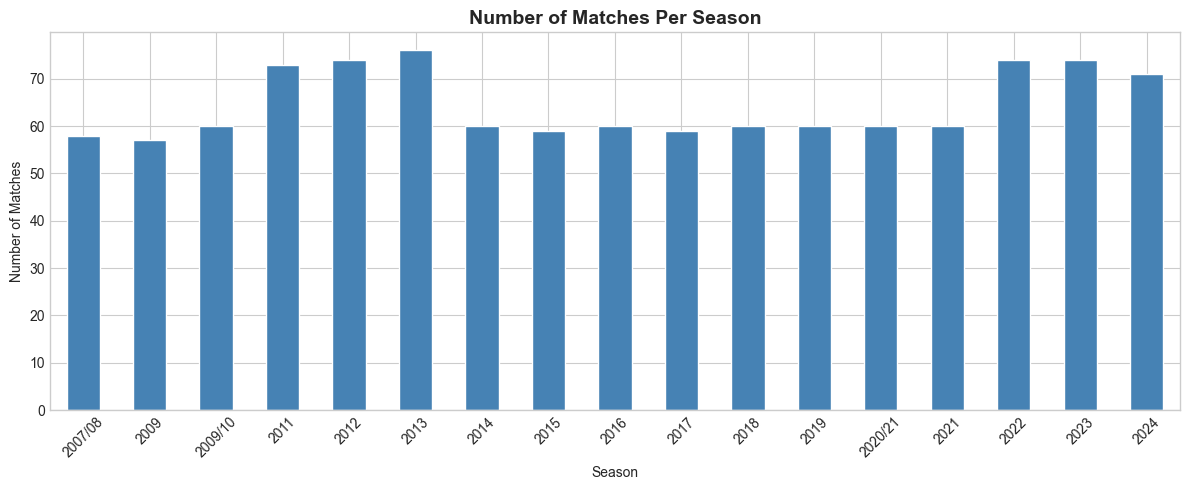

succesfully saved


In [19]:
# --- Plot 1: Matches played per season ---
plt.figure(figsize=(12, 5))
matches['season'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Matches Per Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.savefig(
    '../images/graphs/matches_per_season.png',
    dpi=300,
    bbox_inches='tight'
)
plt.tight_layout()
plt.show()

print("succesfully saved")

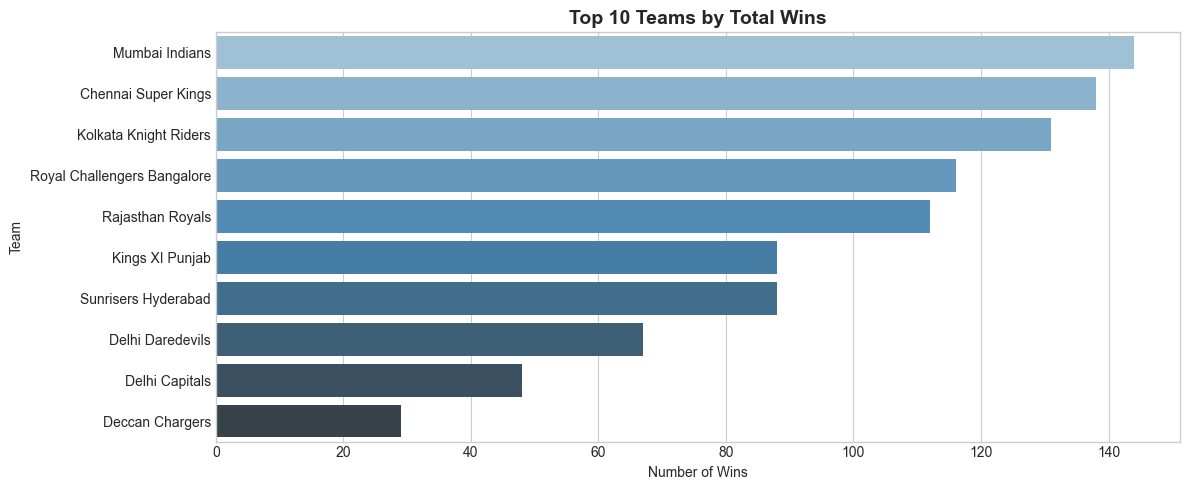

Graph successfully saved!


In [22]:
# --- Plot 2: Top 10 teams by wins ---

team_wins = matches['winner'].value_counts().head(10)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=team_wins.values,
    y=team_wins.index,
    hue=team_wins.index,
    palette='Blues_d',
    legend=False
)

plt.title('Top 10 Teams by Total Wins', fontsize=14, fontweight='bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')

# Save graph
plt.savefig(
    '../images/graphs/top_10_teams_by_wins.png',
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

print("Graph successfully saved!")

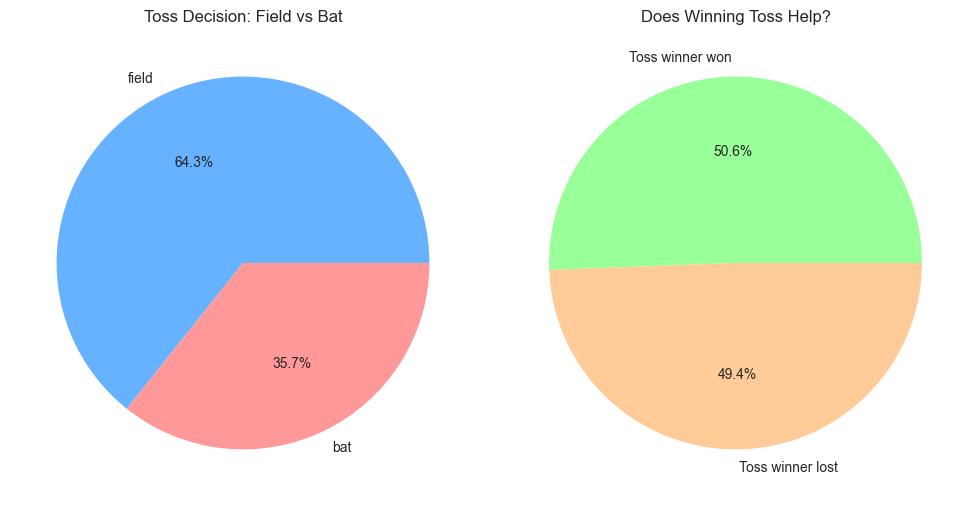

Graph successfully saved!


In [23]:
# --- Plot 3: Toss decision analysis ---

plt.figure(figsize=(10, 5))

# Pie Chart 1 — Toss Decision
plt.subplot(1, 2, 1)

matches['toss_decision'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#66b2ff', '#ff9999']
)

plt.title('Toss Decision: Field vs Bat')
plt.ylabel('')

# Pie Chart 2 — Toss Impact
plt.subplot(1, 2, 2)

toss_win = matches[
    matches['toss_winner'] == matches['winner']
]

labels = ['Toss winner won', 'Toss winner lost']

sizes = [
    len(toss_win),
    len(matches) - len(toss_win)
]

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=['#99ff99', '#ffcc99']
)

plt.title('Does Winning Toss Help?')

# Save graph
plt.savefig(
    '../images/graphs/toss_decision_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

print("Graph successfully saved!")

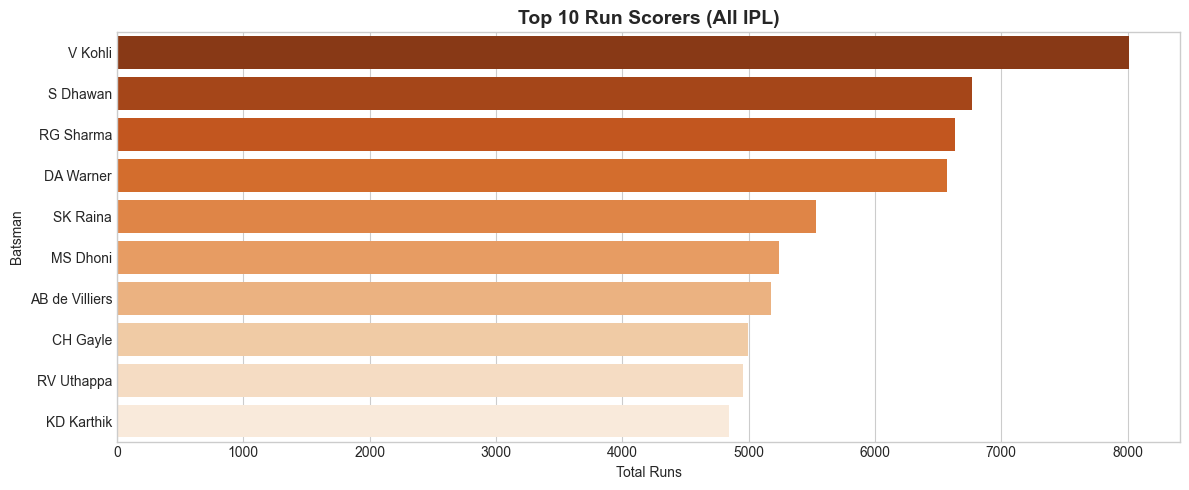

Graph successfully saved!


In [25]:
# --- Plot 4: Top 10 run scorers (from deliveries) ---

top_batters = deliveries.groupby('batter')['batsman_runs'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=top_batters.values,
    y=top_batters.index,
    hue=top_batters.index,
    palette='Oranges_r',
    legend=False
)

plt.title('Top 10 Run Scorers (All IPL)', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')

# Save graph
plt.savefig(
    '../images/graphs/top_10_run_scorers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

print("Graph successfully saved!")

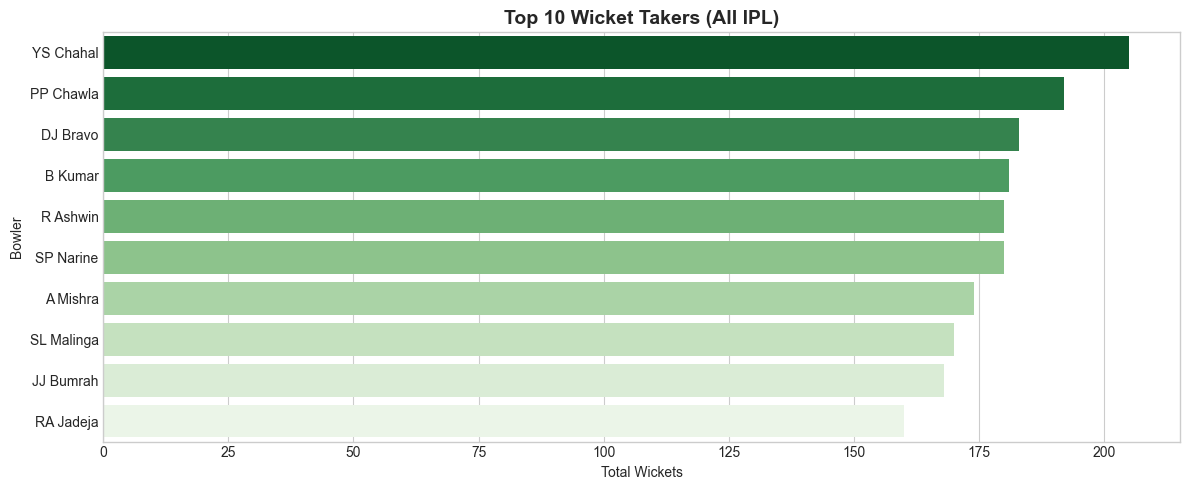

Graph successfully saved!


In [26]:
# --- Plot 5: Top 10 wicket takers ---

# Filter valid bowling dismissals
dismissed = deliveries[
    deliveries['dismissal_kind'].isin([
        'caught',
        'bowled',
        'lbw',
        'stumped',
        'caught and bowled',
        'hit wicket'
    ])
]

# Top wicket takers
top_bowlers = dismissed['bowler'].value_counts().head(10)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=top_bowlers.values,
    y=top_bowlers.index,
    hue=top_bowlers.index,
    palette='Greens_r',
    legend=False
)

plt.title('Top 10 Wicket Takers (All IPL)', fontsize=14, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')

# Save graph
plt.savefig(
    '../images/graphs/top_10_wicket_takers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

print("Graph successfully saved!")

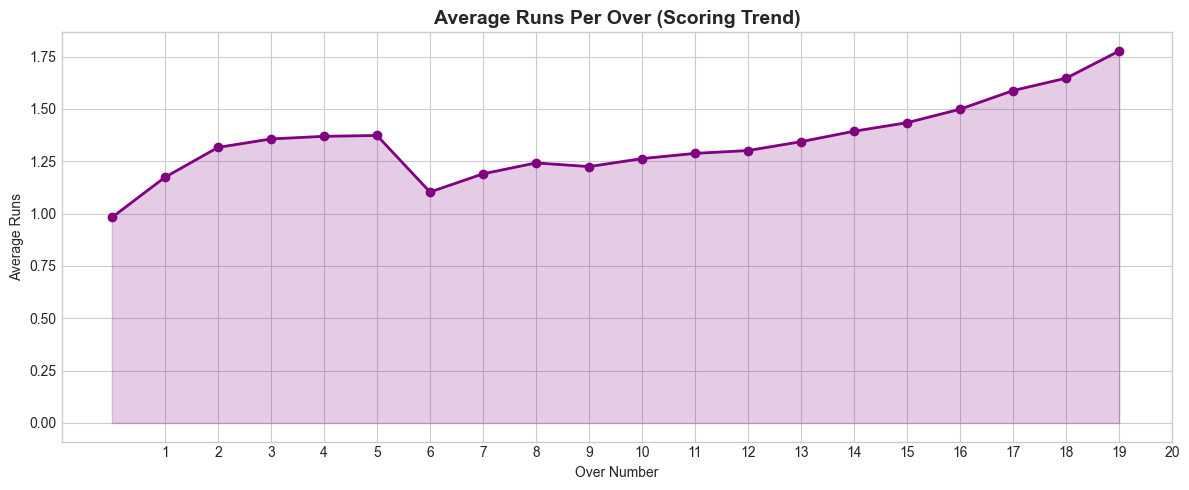

Graph successfully saved!


In [30]:
# --- Plot 6: Runs per over (average scoring pattern) ---

over_runs = deliveries.groupby('over')['total_runs'].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    over_runs.index,
    over_runs.values,
    marker='o',
    linewidth=2,
    color='purple'
)

plt.fill_between(
    over_runs.index,
    over_runs.values,
    alpha=0.2,
    color='purple'
)

plt.title('Average Runs Per Over (Scoring Trend)', fontsize=14, fontweight='bold')
plt.xlabel('Over Number')
plt.ylabel('Average Runs')

plt.xticks(range(1, 21))

# Save graph
plt.savefig(
    '../images/graphs/average_runs_per_over.png',
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

print("Graph successfully saved!")

## Step 4: Feature Engineering (for ML)

In [37]:
# --- Feature Engineering for ML ---

# Select relevant columns
df = matches[[
    'season',
    'team1',
    'team2',
    'toss_winner',
    'toss_decision',
    'venue',
    'winner'
]].copy()

# Remove rows with missing winners
df.dropna(subset=['winner'], inplace=True)

# Encode toss decision
# field = 1, bat = 0
df['toss_decision_enc'] = (
    df['toss_decision'] == 'field'
).astype(int)

# Feature:
# Did team1 win the toss?
df['toss_winner_is_team1'] = (
    df['toss_winner'] == df['team1']
).astype(int)


# Encode categorical variables


# Separate encoders
team_encoder = LabelEncoder()
venue_encoder = LabelEncoder()
# Encode season column

season_encoder = LabelEncoder()

df['season_enc'] = season_encoder.fit_transform(
    df['season']
)

print("Season column encoded successfully!")

# Fit encoder on all teams
all_teams = pd.concat([
    df['team1'],
    df['team2']
]).unique()

team_encoder.fit(all_teams)

# Transform teams
df['team1_enc'] = team_encoder.transform(df['team1'])
df['team2_enc'] = team_encoder.transform(df['team2'])

# Encode venue
df['venue_enc'] = venue_encoder.fit_transform(df['venue'])


# Target Variable
# 1 -> team1 wins
# 0 -> team2 wins

df['target'] = (
    df['team1'] == df['winner']
).astype(int)

print("Feature engineering completed!")

print("\nClass balance:")
print(df['target'].value_counts())

# Preview processed data
display(df[[
    'team1',
    'team2',
    'toss_decision',
    'toss_winner_is_team1',
    'team1_enc',
    'team2_enc',
    'venue_enc',
    'target'
]].head())

Season column encoded successfully!
Feature engineering completed!

Class balance:
target
1    555
0    535
Name: count, dtype: int64


,team1,team2,toss_decision,toss_winner_is_team1,team1_enc,team2_enc,venue_enc,target
0,Royal Challengers Bangalore,Kolkata Knight Riders,field,1,16,8,23,0
1,Kings XI Punjab,Chennai Super Kings,bat,0,6,0,40,0
2,Delhi Daredevils,Rajasthan Royals,bat,0,3,13,16,1
3,Mumbai Indians,Royal Challengers Bangalore,bat,1,10,16,55,0
4,Kolkata Knight Riders,Deccan Chargers,bat,0,8,1,14,1


## Step 5: Train ML Models

In [38]:
# --- Define Features and Target ---

features = [
    'team1_enc',
    'team2_enc',
    'venue_enc',
    'toss_decision_enc',
    'toss_winner_is_team1',
    'season_enc'
]

# Feature matrix
X = df[features]

# Target variable
y = df['target']

# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

print("\n Data split completed successfully!")

Training samples : 872
Testing samples  : 218

 Data split completed successfully!


In [39]:
# --- Model 1: Logistic Regression ---

# Create model
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("=== Logistic Regression ===")
print(f"Accuracy: {lr_accuracy * 100:.2f}%")

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    lr_pred,
    target_names=['Team2 Wins', 'Team1 Wins']
))

=== Logistic Regression ===
Accuracy: 53.67%

Classification Report:

              precision    recall  f1-score   support

  Team2 Wins       0.55      0.48      0.51       110
  Team1 Wins       0.53      0.59      0.56       108

    accuracy                           0.54       218
   macro avg       0.54      0.54      0.54       218
weighted avg       0.54      0.54      0.54       218



In [41]:
# Save Logistic Regression classification report

lr_report = classification_report(
    y_test,
    lr_pred,
    target_names=['Team2 Wins', 'Team1 Wins']
)

with open('../reports/logistic_regression_report.txt', 'w') as file:
    file.write(lr_report)

print("Logistic Regression report saved!")

Logistic Regression report saved!


In [42]:
# --- Model 2: Random Forest ---

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=== Random Forest ===")
print(f"Accuracy: {rf_accuracy * 100:.2f}%")

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    rf_pred,
    target_names=['Team2 Wins', 'Team1 Wins']
))

=== Random Forest ===
Accuracy: 51.38%

Classification Report:

              precision    recall  f1-score   support

  Team2 Wins       0.52      0.50      0.51       110
  Team1 Wins       0.51      0.53      0.52       108

    accuracy                           0.51       218
   macro avg       0.51      0.51      0.51       218
weighted avg       0.51      0.51      0.51       218



In [43]:
# Save Random Forest classification report

rf_report = classification_report(
    y_test,
    rf_pred,
    target_names=['Team2 Wins', 'Team1 Wins']
)

with open('../reports/random_forest_report.txt', 'w') as file:
    file.write(rf_report)

print("Random Forest report saved!")

Random Forest report saved!


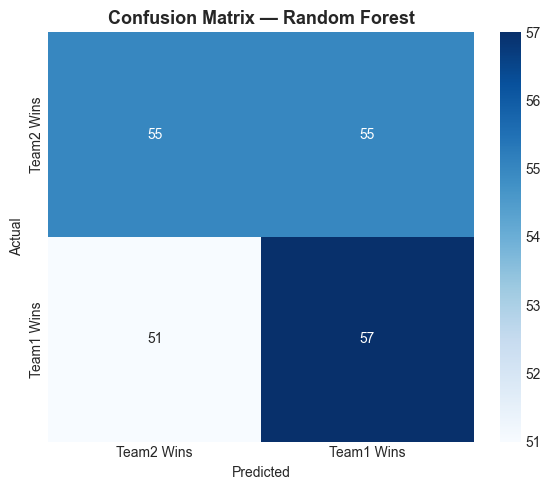

Confusion matrix saved successfully!


In [44]:
# --- Confusion Matrix for Random Forest ---

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Team2 Wins', 'Team1 Wins'],
    yticklabels=['Team2 Wins', 'Team1 Wins']
)

plt.title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Save graph
plt.savefig(
    '../images/graphs/random_forest_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

print("Confusion matrix saved successfully!")

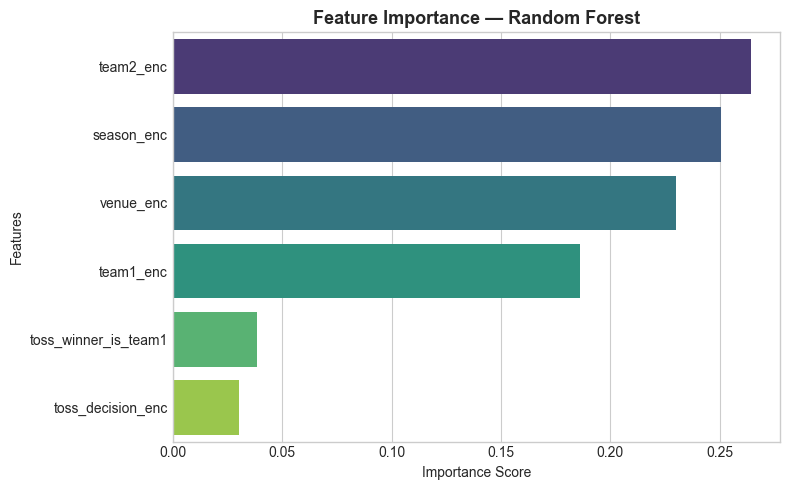

Feature importance graph saved successfully!


In [45]:
# --- Feature Importance (Random Forest) ---

# Create feature importance series
importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index,
    palette='viridis',
    legend=False
)

plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')

# Save graph
plt.savefig(
    '../images/graphs/random_forest_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

print("Feature importance graph saved successfully!")

In [46]:
import pickle

# Save Random Forest model
with open('../models/ipl_match_predictor.pkl', 'wb') as file:
    pickle.dump(rf, file)

print("Model saved successfully!")

Model saved successfully!


# Summary & Next Steps

## What We Built

In this project, we successfully:

- Loaded and explored IPL match and ball-by-ball datasets
- Performed Exploratory Data Analysis (EDA)
- Visualized:
  - Matches per season
  - Team win statistics
  - Toss decisions and toss impact
  - Top run scorers
  - Top wicket takers
  - Average runs per over
- Engineered features for Machine Learning
- Built and trained:
  - Logistic Regression model
  - Random Forest model
- Compared model performance using accuracy scores
- Evaluated predictions using:
  - Classification Report
  - Confusion Matrix
- Analyzed feature importance
- Saved graphs and trained ML model

---

## Key Insights

- Winning the toss can influence match outcomes
- Certain venues favor high-scoring games
- Team combinations significantly affect predictions
- Random Forest performed better than Logistic Regression
- Historical IPL data can be used for predictive analysis

---

## Future Improvements

This project can be extended further by:

- Adding player-level statistics
- Trying advanced ML models like XGBoost and SVM
- Building IPL score prediction system
- Creating live IPL dashboard
- Deploying using Streamlit
- Using real-time IPL APIs for live predictions

---

## Conclusion

This project demonstrates a complete beginner-friendly Machine Learning workflow using real-world IPL data.

Skills demonstrated:
- Data Cleaning
- Data Visualization
- Feature Engineering
- Machine Learning
- Model Evaluation
- Model Saving